# Employee Policy Assistant – Embedding Generation and Semantic Similarity Analysis

## Problem Statement

A company is building an AI-powered Employee Policy Assistant.

The policy documents have already been divided into chunks.

Before storing the chunks in a Vector Database, the company wants to generate embeddings and analyze semantic similarity between employee queries and policy document chunks.

Your task is to convert document chunks into embeddings and study how embeddings capture meaning rather than exact words.

---

## Dataset

Use the following policy chunks:

```python
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]
```

---

# Task 1: Load Embedding Model

## Objective

Load a Sentence Transformer embedding model.

## Requirements

Use:

- all-MiniLM-L6-v2

## Deliverables

Display:

- Model Name
- Embedding Dimension

---

# Task 2: Generate Embeddings

## Objective

Convert all policy chunks into vector embeddings.

## Deliverables

Display:

- Chunk Content
- Embedding Shape

### Example

**Chunk:**

Employees receive 12 casual leaves annually.

**Embedding Shape:**

```python
(384,)
```

---

# Task 3: Analyze Embedding Vectors

## Objective

Understand how text becomes numerical vectors.

## Requirements

Display:

- First 20 values of the embedding vector

### Example

```python
[
 0.123,
 0.451,
 -0.221,
 ...
]
```

## Analysis

Explain:

- Why embeddings contain decimal values.
- What each dimension represents.
- How embeddings capture semantic meaning.

---

# Task 4: Generate Query Embeddings

## Objective

Convert employee questions into embeddings.

## Queries

```python
queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]
```

## Deliverables

Display:

- Query
- Embedding Shape

---

# Task 5: Semantic Similarity Analysis

## Objective

Compare meaning between employee queries and policy chunks.

## Requirements

Calculate cosine similarity between:

- Query Embeddings
- Chunk Embeddings

## Deliverables

Display:

- Query
- Chunk
- Similarity Score

---

# Task 6: Identify Most Similar Chunk

## Objective

Find the policy chunk whose meaning is closest to the employee query.

### Example

**Query:**

How many casual leaves are allowed?

**Expected Match:**

Employees receive 12 casual leaves annually.

## Deliverables

Display:

- Query
- Most Similar Chunk
- Similarity Score

---

# Task 7: Similar Meaning vs Different Meaning

## Objective

Observe how embeddings capture semantic meaning.

### Sentence Pair 1

```text
Employees receive 12 casual leaves.
Workers are entitled to 12 annual leaves.
```

### Sentence Pair 2

```text
Employees receive 12 casual leaves.
Travel expenses are reimbursed within 30 days.
```

## Deliverables

Calculate:

- Cosine Similarity for Pair 1
- Cosine Similarity for Pair 2

## Analysis

Answer:

- Why Pair 1 has higher similarity than Pair 2.
- How embeddings understand semantic relationships.
- Why exact word matching is not required.

---

# Task 8: Embedding Visualization

## Objective

Visualize embeddings using PCA or t-SNE.

## Deliverables

Plot:

- Chunk Embeddings
- Query Embeddings

## Analysis

Explain:

- Why semantically similar texts appear closer together.
- How dimensionality reduction helps visualize embeddings.
- What insights can be obtained from the visualization.

---

# Final Conclusion

Summarize:

1. What are embeddings?
2. Why are embeddings important in RAG systems?
3. How does cosine similarity help retrieve relevant information?
4. Which chunk was most relevant for each employee query?
5. Key observations from semantic similarity analysis.

In [ ]:
#Install Libraries
!pip install sentence-transformers scikit-learn matplotlib pandas -q

# ***Task 1: Load Embedding Model***

In [1]:
from sentence_transformers import SentenceTransformer

model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)

print("Model Name:", model_name)

sample_embedding = model.encode("sample text")

print("Embedding Dimension:", len(sample_embedding))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Name: all-MiniLM-L6-v2
Embedding Dimension: 384


# ***Dataset***

In [2]:
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

# ***Task 2: Generate Embeddings***

In [3]:
chunk_embeddings = model.encode(chunks)

for chunk, emb in zip(chunks, chunk_embeddings):

    print("\nChunk:")
    print(chunk)

    print("Embedding Shape:")
    print(emb.shape)

    print("-"*60)


Chunk:
Employees receive 12 casual leaves annually.
Embedding Shape:
(384,)
------------------------------------------------------------

Chunk:
Employees receive 15 sick leaves annually.
Embedding Shape:
(384,)
------------------------------------------------------------

Chunk:
Employees may work from home twice per week.
Embedding Shape:
(384,)
------------------------------------------------------------

Chunk:
Travel expenses are reimbursed within 30 days.
Embedding Shape:
(384,)
------------------------------------------------------------

Chunk:
All employees are covered under company medical insurance.
Embedding Shape:
(384,)
------------------------------------------------------------


# ***Task 3: Analyze Embedding Vectors***

In [4]:
for i, emb in enumerate(chunk_embeddings):

    print(f"\nChunk {i+1}")

    print("First 20 Values:")

    print(emb[:20])

    print("-"*60)


Chunk 1
First 20 Values:
[ 0.0618362   0.01376683  0.03366624  0.0186107   0.03135883  0.06788085
 -0.01135737 -0.01733116 -0.07070484  0.01901567  0.1098766   0.05092814
 -0.0489678  -0.04620624 -0.03665631  0.00247606 -0.06287521  0.00541349
  0.03131726 -0.07714854]
------------------------------------------------------------

Chunk 2
First 20 Values:
[ 0.06126364  0.05009587  0.03596273  0.00253234  0.05886815  0.03007157
  0.00620263 -0.00012556 -0.02327204 -0.00199277  0.09904463  0.02734741
 -0.01499912 -0.05225241 -0.05824455  0.00689516 -0.01921887 -0.00015441
 -0.01112937 -0.05974312]
------------------------------------------------------------

Chunk 3
First 20 Values:
[ 0.00968149 -0.0412338   0.04907801 -0.00404767 -0.02251745  0.02833883
 -0.01207532 -0.07281487 -0.12298819 -0.10405417  0.00648229  0.07671163
 -0.05534682 -0.00503631  0.08058558 -0.04653181 -0.03970739 -0.05092216
  0.05236141 -0.08418249]
------------------------------------------------------------

Chu

In [5]:
print("""
Why do embeddings contain decimal values?

Embeddings are generated by neural networks.

Each value represents learned semantic features.

Decimal values indicate the importance and relationship
between words and concepts in high-dimensional space.
""")


Why do embeddings contain decimal values?

Embeddings are generated by neural networks.

Each value represents learned semantic features.

Decimal values indicate the importance and relationship
between words and concepts in high-dimensional space.



# ***Task 4: Generate Query Embeddings***

In [6]:
queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]

In [7]:
query_embeddings = model.encode(queries)

for query, emb in zip(queries, query_embeddings):

    print("\nQuery:")
    print(query)

    print("Embedding Shape:")
    print(emb.shape)

    print("-"*60)


Query:
How many casual leaves are allowed?
Embedding Shape:
(384,)
------------------------------------------------------------

Query:
Can employees work remotely?
Embedding Shape:
(384,)
------------------------------------------------------------

Query:
What is the travel reimbursement process?
Embedding Shape:
(384,)
------------------------------------------------------------

Query:
Do employees have medical insurance?
Embedding Shape:
(384,)
------------------------------------------------------------


# ***Task 5: Semantic Similarity Analysis***

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
for query, q_emb in zip(queries, query_embeddings):

    print("\nQuery:", query)
    print("="*80)

    similarities = cosine_similarity(
        [q_emb],
        chunk_embeddings
    )[0]

    for chunk, score in zip(chunks, similarities):

        print("\nChunk:", chunk)
        print("Similarity Score:", round(score,4))


Query: How many casual leaves are allowed?

Chunk: Employees receive 12 casual leaves annually.
Similarity Score: 0.6552

Chunk: Employees receive 15 sick leaves annually.
Similarity Score: 0.411

Chunk: Employees may work from home twice per week.
Similarity Score: 0.1763

Chunk: Travel expenses are reimbursed within 30 days.
Similarity Score: 0.0493

Chunk: All employees are covered under company medical insurance.
Similarity Score: 0.0472

Query: Can employees work remotely?

Chunk: Employees receive 12 casual leaves annually.
Similarity Score: 0.1963

Chunk: Employees receive 15 sick leaves annually.
Similarity Score: 0.23

Chunk: Employees may work from home twice per week.
Similarity Score: 0.4834

Chunk: Travel expenses are reimbursed within 30 days.
Similarity Score: -0.0254

Chunk: All employees are covered under company medical insurance.
Similarity Score: 0.3006

Query: What is the travel reimbursement process?

Chunk: Employees receive 12 casual leaves annually.
Similarity

# ***Task 6: Identify Most Similar Chunk***

In [10]:
for query, q_emb in zip(queries, query_embeddings):

    similarities = cosine_similarity(
        [q_emb],
        chunk_embeddings
    )[0]

    best_index = similarities.argmax()

    print("\nQuery:")
    print(query)

    print("\nMost Similar Chunk:")
    print(chunks[best_index])

    print("\nSimilarity Score:")
    print(round(similarities[best_index],4))

    print("-"*80)


Query:
How many casual leaves are allowed?

Most Similar Chunk:
Employees receive 12 casual leaves annually.

Similarity Score:
0.6552
--------------------------------------------------------------------------------

Query:
Can employees work remotely?

Most Similar Chunk:
Employees may work from home twice per week.

Similarity Score:
0.4834
--------------------------------------------------------------------------------

Query:
What is the travel reimbursement process?

Most Similar Chunk:
Travel expenses are reimbursed within 30 days.

Similarity Score:
0.7255
--------------------------------------------------------------------------------

Query:
Do employees have medical insurance?

Most Similar Chunk:
All employees are covered under company medical insurance.

Similarity Score:
0.803
--------------------------------------------------------------------------------


# ***Task 7: Similar Meaning vs Different Meaning***

In [11]:
pair1 = [
    "Employees receive 12 casual leaves.",
    "Workers are entitled to 12 annual leaves."
]

pair2 = [
    "Employees receive 12 casual leaves.",
    "Travel expenses are reimbursed within 30 days."
]

In [12]:
emb1 = model.encode(pair1)

similarity1 = cosine_similarity(
    [emb1[0]],
    [emb1[1]]
)[0][0]

print("Pair 1 Similarity:")
print(round(similarity1,4))

Pair 1 Similarity:
0.771


In [13]:
emb2 = model.encode(pair2)

similarity2 = cosine_similarity(
    [emb2[0]],
    [emb2[1]]
)[0][0]

print("Pair 2 Similarity:")
print(round(similarity2,4))

Pair 2 Similarity:
0.175


In [14]:
print("""
Pair 1 has higher similarity because both sentences
talk about employee leave benefits.

Pair 2 has lower similarity because one sentence
discusses leave policy while the other discusses travel reimbursement.

Embeddings capture meaning rather than exact words.
""")


Pair 1 has higher similarity because both sentences
talk about employee leave benefits.

Pair 2 has lower similarity because one sentence
discusses leave policy while the other discusses travel reimbursement.

Embeddings capture meaning rather than exact words.



# ***Task 8: Embedding Visualization***

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [16]:
all_texts = chunks + queries

all_embeddings = model.encode(all_texts)

pca = PCA(n_components=2)

reduced = pca.fit_transform(all_embeddings)

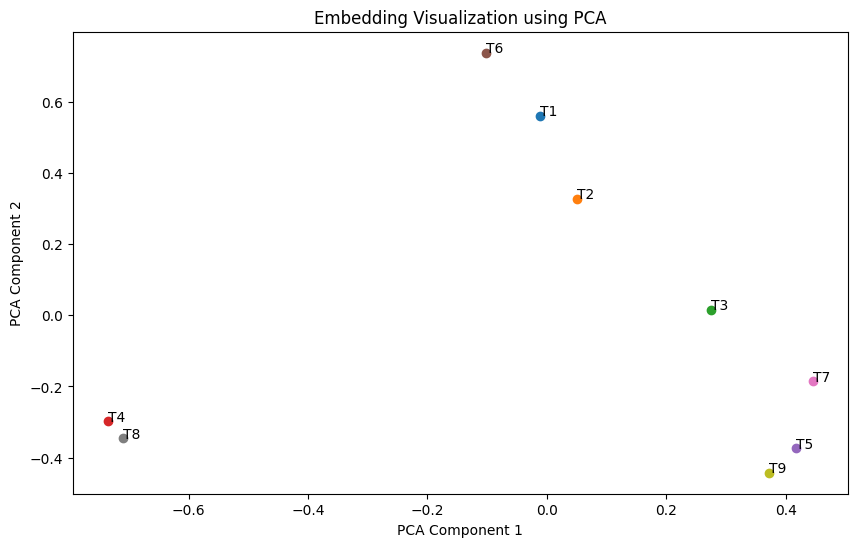

In [17]:
plt.figure(figsize=(10,6))

for i, txt in enumerate(all_texts):

    x = reduced[i,0]
    y = reduced[i,1]

    plt.scatter(x,y)

    plt.annotate(
        f"T{i+1}",
        (x,y)
    )

plt.title("Embedding Visualization using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [18]:
print("""
Semantically similar texts appear closer together
because their embeddings are located near each other
in vector space.

PCA reduces 384 dimensions into 2 dimensions,
allowing visualization.

Clusters indicate related topics such as
leave policy, work from home, travel, and insurance.
""")


Semantically similar texts appear closer together
because their embeddings are located near each other
in vector space.

PCA reduces 384 dimensions into 2 dimensions,
allowing visualization.

Clusters indicate related topics such as
leave policy, work from home, travel, and insurance.



# ***Final Conclusion***

In [19]:
print("""
FINAL CONCLUSION

1. Embeddings convert text into numerical vectors.

2. Similar meanings produce similar vectors.

3. Cosine similarity measures closeness between vectors.

4. Employee queries successfully matched relevant policy chunks.

5. Embeddings are the foundation of semantic search
and Retrieval-Augmented Generation (RAG) systems.
""")


FINAL CONCLUSION

1. Embeddings convert text into numerical vectors.

2. Similar meanings produce similar vectors.

3. Cosine similarity measures closeness between vectors.

4. Employee queries successfully matched relevant policy chunks.

5. Embeddings are the foundation of semantic search
and Retrieval-Augmented Generation (RAG) systems.

